# SpikeYOLO — Detection de Drones sur FRED

**Architecture** : SpikeYOLO (BICLab, ECCV 2024 Best Paper Candidate)  
**Source** : https://github.com/BICLab/SpikeYOLO  
**Dataset** : FRED — Florence RGB-Event Drone Dataset

## Pourquoi SpikeYOLO (BICLab) ?

| Critere | SpikeYOLO camarade | **SpikeYOLO BICLab** |
|---|---|---|
| Publication | Non publie | **ECCV 2024 Best Paper Candidate** |
| Base | spikingjelly brut | **ultralytics (stable)** |
| Neurone | LIF classique | **I-LIF (Integer-valued)** |
| mAP COCO | ~45% | **66.2% mAP@50** |
| Stabilite | Plante | **Production-ready** |

## Architecture SpikeYOLO
SpikeYOLO **simplifie YOLOv8** et remplace les blocs CNN par des **meta SNN blocks** :
- Backbone : Spiking DenseNet avec neurones **I-LIF**
- Neck : Spiking FPN (Feature Pyramid Network)
- Head : Detection multi-echelle standard

Le neurone **I-LIF** (Integer-valued Leaky Integrate-and-Fire) :
- Entraine avec des valeurs entieres (reduit l'erreur de quantification)
- Inference avec des vrais spikes binaires (ultra basse consommation)

## Plan
1. Telechargement FRED
2. Installation SpikeYOLO depuis GitHub
3. Export FRED au format YOLO
4. Configuration et entrainement
5. Evaluation et visualisation
6. Sauvegarde

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
Tesla P100-PCIE-16GB


---
## Cellule 0 — Telechargement de FRED

Si FRED est deja dans `/kaggle/working/FRED/train/`, cette cellule le detecte et passe.

In [2]:
import os

if os.path.exists('/kaggle/working/FRED/train/0'):
    print('FRED deja present.')
else:
    print('Telechargement de FRED...')
    os.makedirs('/kaggle/working/FRED/train', exist_ok=True)
    os.makedirs('/kaggle/working/FRED/test',  exist_ok=True)

    for seq in ['0', '1', '2']:
        !wget -q "https://huggingface.co/datasets/GabrieleMagrini/FRED/resolve/main/train/{seq}.zip" \
               -O /kaggle/working/FRED/train/{seq}.zip
        !unzip -q /kaggle/working/FRED/train/{seq}.zip -d /kaggle/working/FRED/train/
        print(f'  Sequence {seq} OK')

print('Contenu FRED/train :')
!ls /kaggle/working/FRED/train/

FRED deja present.
Contenu FRED/train :
0  0.zip  1  1.zip  2  2.zip


---
## Cellule 1 — Installation de SpikeYOLO (BICLab)

On clone le repo officiel et on installe les dependances.
SpikeYOLO est **base sur ultralytics**, donc l'installation est propre.

In [3]:
import os

# Clone du repo SpikeYOLO officiel (BICLab, ECCV 2024)
if not os.path.exists('/kaggle/working/SpikeYOLO'):
    !git clone https://github.com/BICLab/SpikeYOLO.git /kaggle/working/SpikeYOLO
    print('SpikeYOLO clone.')
else:
    print('SpikeYOLO deja present.')

# Installation des dependances
!pip install spikingjelly==0.0.0.0.14 -q
!pip install timm einops -q

# Installation de SpikeYOLO comme package (mode editable)
os.chdir('/kaggle/working/SpikeYOLO')
!pip install -e . -q

print('\nVerification imports...')
import torch
from spikingjelly.activation_based import neuron, functional, surrogate
print(f'PyTorch    : {torch.__version__}')
print(f'CUDA       : {torch.cuda.is_available()}')
print(f'GPU        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Non dispo"}')
print('spikingjelly OK')
print('\nSpikeYOLO installe avec succes !')

SpikeYOLO deja present.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 12.2 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done

Verification imports...
PyTorch    : 2.9.0+cu126
CUDA       : True
GPU        : Tesla P100-PCIE-16GB
spikingjelly OK

SpikeYOLO installe avec succes !


---
## Cellule 2 — Remise en contexte et fonctions FRED

Meme logique que le notebook de reference : parsing des annotations et construction des listes d'images.

In [4]:
import os
import sys
import torch
import numpy as np
from PIL import Image
from collections import defaultdict

# Chemins
FRED_TRAIN = '/kaggle/working/FRED/train'
IMG_W, IMG_H = 1280, 720

train_seqs = sorted([f for f in os.listdir(FRED_TRAIN) if f.isdigit()])
print(f'Sequences disponibles : {train_seqs}')

def fred_to_yolo(x1, y1, x2, y2, img_w=IMG_W, img_h=IMG_H):
    """Convertit les coordonnees absolues FRED en format YOLO normalise."""
    xc = ((x1 + x2) / 2.0) / img_w
    yc = ((y1 + y2) / 2.0) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return (max(0., min(1., xc)), max(0., min(1., yc)),
            max(0., min(1., w)),  max(0., min(1., h)))

def parse_fred_annotations(seq_path):
    """Parse le fichier coordinates.txt d'une sequence FRED."""
    annots = defaultdict(list)
    annot_file = os.path.join(seq_path, 'coordinates.txt')
    with open(annot_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(':')
            if len(parts) < 2:
                continue
            timestamp = parts[0].strip()
            values    = parts[1].strip().split(',')
            if len(values) < 4:
                continue
            x1, y1, x2, y2 = [float(v.strip()) for v in values[:4]]
            xc, yc, w, h = fred_to_yolo(x1, y1, x2, y2)
            annots[timestamp].append([0, xc, yc, w, h])
    return annots

def build_sample_list(seq_path, annots):
    """Associe chaque frame a ses annotations par proximite temporelle."""
    frames_dir = os.path.join(seq_path, 'Event', 'Frames')
    if not os.path.exists(frames_dir):
        return []
    frame_files  = sorted([f for f in os.listdir(frames_dir) if f.endswith(('.png', '.jpg'))])
    annot_ts     = sorted(annots.keys(), key=lambda x: float(x))
    annot_floats = [float(ts) for ts in annot_ts]
    samples = []
    for fname in frame_files:
        try:
            frame_ts = float(fname.split('_')[-1].replace('.png','').replace('.jpg','')) / 1e6
        except:
            continue
        diffs = [abs(frame_ts - ats) for ats in annot_floats]
        idx   = diffs.index(min(diffs))
        if diffs[idx] < 0.050:
            samples.append((os.path.join(frames_dir, fname), annots[annot_ts[idx]]))
    return samples

print('Fonctions FRED chargees.')
print('Contexte pret !')

Sequences disponibles : ['0', '1', '2']
Fonctions FRED chargees.
Contexte pret !


---
## Cellule 3 — Export FRED au format YOLO sur disque

SpikeYOLO (base ultralytics) attend les donnees dans une structure de dossiers precise :
```
FRED_YOLO/
   images/train/   <- frames PNG 640x640
   images/val/
   labels/train/   <- annotations .txt (format YOLO)
   labels/val/
```
Split : sequences 0+1 = train | sequence 2 = val

Duree : ~3-5 minutes

In [5]:
import shutil
from PIL import Image

YOLO_ROOT = '/kaggle/working/FRED_YOLO'

for split in ['train', 'val']:
    os.makedirs(f'{YOLO_ROOT}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_ROOT}/labels/{split}', exist_ok=True)

print('Structure creee.')

split_map = {
    train_seqs[0]: 'train',
    train_seqs[1]: 'train',
    train_seqs[2]: 'val'
}

total_train, total_val = 0, 0

for seq_id, split in split_map.items():
    seq_path = os.path.join(FRED_TRAIN, seq_id)
    annots   = parse_fred_annotations(seq_path)
    samples  = build_sample_list(seq_path, annots)
    print(f'  Sequence {seq_id} -> {split} ({len(samples)} frames)')

    for frame_path, boxes in samples:
        fname = f'seq{seq_id}_{os.path.basename(frame_path)}'
        stem  = os.path.splitext(fname)[0]

        img = Image.open(frame_path).convert('RGB')
        img = img.resize((640, 640), Image.BILINEAR)
        img.save(f'{YOLO_ROOT}/images/{split}/{stem}.png')

        with open(f'{YOLO_ROOT}/labels/{split}/{stem}.txt', 'w') as f:
            for box in boxes:
                cls, xc, yc, w, h = box
                f.write(f'{int(cls)} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n')

        if split == 'train': total_train += 1
        else:                total_val   += 1

print(f'\nExport termine !')
print(f'  Train : {total_train} images')
print(f'  Val   : {total_val} images')

Structure creee.
  Sequence 0 -> train (1910 frames)
  Sequence 1 -> train (2380 frames)
  Sequence 2 -> val (3032 frames)

Export termine !
  Train : 4290 images
  Val   : 3032 images


---
## Cellule 4 — Fichier de configuration YAML

SpikeYOLO lit un fichier YAML qui decrit le dataset (meme format qu'ultralytics/YOLOv8).

In [6]:
import yaml

YAML_PATH = '/kaggle/working/fred_drone.yaml'

config = {
    'path'  : YOLO_ROOT,
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 1,
    'names' : ['drone']
}

with open(YAML_PATH, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('fred_drone.yaml cree :')
print('-' * 30)
with open(YAML_PATH) as f:
    print(f.read())
print('-' * 30)

fred_drone.yaml cree :
------------------------------
names:
- drone
nc: 1
path: /kaggle/working/FRED_YOLO
train: images/train
val: images/val

------------------------------


---
## Cellule 5 — Adaptation de SpikeYOLO pour 1 classe (drone)

SpikeYOLO utilise un fichier de config YAML pour le modele.
On cree un fichier de config adapte a notre cas : 1 classe, taille nano.

### Comment fonctionne le neurone I-LIF ?
```
V(t) = beta * V(t-1) + X(t)          # Integration
spike = 1 si V(t) >= seuil, sinon 0  # Emission
V(t) = V(t) - spike * seuil           # Reset soft
```
La difference avec LIF classique : les valeurs internes sont **entieres** pendant l'entrainement, ce qui reduit drastiquement l'erreur de quantification lors du passage en mode spike binaire a l'inference.

In [7]:
import os

SPIKEYOLO_DIR = '/kaggle/working/SpikeYOLO'

print('Contenu du repo SpikeYOLO :')
!ls /kaggle/working/SpikeYOLO/
print('\nContenu du dossier config (si present) :')
!ls /kaggle/working/SpikeYOLO/config/ 2>/dev/null || echo 'Pas de dossier config separe'

Contenu du repo SpikeYOLO :
69M_best.pt		      figure1.jpg	setup.cfg
coco2yolo.py		      LICENSE		setup.py
config			      logs_23M		SpikeYOLO_for_Gen1
convert_integer_to_binary.py  MANIFEST.in	state.db
detect.py		      mkdocs.yml	test.py
docker			      picture		train.py
docs			      power_cal.xlsx	train.sh
environment.yaml	      README.md		ultralytics
examples		      requirements.txt	ultralytics.egg-info

Contenu du dossier config (si present) :
Arial.ttf  settings.yaml


In [8]:
# Creation du fichier de config modele SpikeYOLO adapte a FRED
# On cible le modele 23M (version nano de SpikeYOLO)

MODEL_CONFIG = '/kaggle/working/spikeyolo_fred.yaml'

model_cfg = """
# SpikeYOLO config adapte pour FRED (1 classe : drone)
# Base : SpikeYOLO 23M (ECCV 2024)

nc: 1          # Nombre de classes
scales:        # [depth, width, max_channels]
  n: [0.50, 0.25, 1024]  # nano

backbone:
  # [from, repeats, module, args]
  - [-1, 1, SpikeConv,      [64, 3, 2]]   # 0-P1/2
  - [-1, 1, SpikeConv,      [128, 3, 2]]  # 1-P2/4
  - [-1, 3, SpikeDenseBlock,[128]]        # 2
  - [-1, 1, SpikeConv,      [256, 3, 2]]  # 3-P3/8
  - [-1, 6, SpikeDenseBlock,[256]]        # 4
  - [-1, 1, SpikeConv,      [512, 3, 2]]  # 5-P4/16
  - [-1, 6, SpikeDenseBlock,[512]]        # 6
  - [-1, 1, SpikeConv,      [1024,3, 2]]  # 7-P5/32
  - [-1, 3, SpikeDenseBlock,[1024]]       # 8
  - [-1, 1, SPPF,           [1024, 5]]    # 9

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 10
  - [[-1, 6], 1, Concat, [1]]                    # 11
  - [-1, 3, SpikeDenseBlock, [512]]              # 12
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 13
  - [[-1, 4], 1, Concat, [1]]                    # 14
  - [-1, 3, SpikeDenseBlock, [256]]              # 15 P3/8-small
  - [-1, 1, SpikeConv, [256, 3, 2]]             # 16
  - [[-1, 12], 1, Concat, [1]]                   # 17
  - [-1, 3, SpikeDenseBlock, [512]]              # 18 P4/16-medium
  - [-1, 1, SpikeConv, [512, 3, 2]]             # 19
  - [[-1, 9], 1, Concat, [1]]                    # 20
  - [-1, 3, SpikeDenseBlock, [1024]]             # 21 P5/32-large
  - [[15, 18, 21], 1, Detect, [nc]]             # 22 Detect
"""

with open(MODEL_CONFIG, 'w') as f:
    f.write(model_cfg)

print('Config modele SpikeYOLO cree.')

Config modele SpikeYOLO cree.


---
## Cellule 6 — Entrainement SpikeYOLO sur FRED

SpikeYOLO utilise le meme script d'entrainement qu'ultralytics (train.py).
On l'appelle en ligne de commande depuis le dossier SpikeYOLO.

### Parametres importants
- **T=4** : 4 timesteps SNN (simulation temporelle des spikes)
- **D=4** : profondeur des blocs SNN
- **epochs=20** : convergence complete
- **imgsz=512** : taille standard
- **batch=4** : adapte a T4 avec T=4 timesteps (memoire x4)

In [9]:
# Fix compatibilite PyTorch 2.6 avec les checkpoints SpikeYOLO
import torch
import ultralytics.nn.tasks as tasks

# Autorise le chargement du modele SpikeYOLO (source officielle BICLab = fiable)
torch.serialization.add_safe_globals([tasks.DetectionModel])

# Patch de torch.load pour forcer weights_only=False
original_load = torch.load
def patched_load(f, *args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(f, *args, **kwargs)
torch.load = patched_load

print('Fix PyTorch 2.6 applique.')
print('Relance maintenant la cellule 6.')

2026-03-24 07:45:14.010902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774338314.195817      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774338314.245545      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774338314.674016      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774338314.674064      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774338314.674067      55 computation_placer.cc:177] computation placer alr

Fix PyTorch 2.6 applique.
Relance maintenant la cellule 6.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [10]:
# Patch direct dans le fichier source de SpikeYOLO
import re

tasks_path = '/kaggle/working/SpikeYOLO/ultralytics/nn/tasks.py'

with open(tasks_path, 'r') as f:
    content = f.read()

# Remplace torch.load(...) par torch.load(..., weights_only=False)
content_patched = content.replace(
    "torch.load(file, map_location='cpu')",
    "torch.load(file, map_location='cpu', weights_only=False)"
)

with open(tasks_path, 'w') as f:
    f.write(content_patched)

print('Patch applique dans tasks.py')
print('Verification :')
# Verifie que le patch est bien la
matches = [l for l in content_patched.split('\n') if 'torch.load' in l and 'map_location' in l]
for m in matches:
    print(f'  {m.strip()}')
print('\nRelance maintenant la cellule 6.')

Patch applique dans tasks.py
Verification :
  return torch.load(file, map_location='cpu', weights_only=False), file  # load
  return torch.load(file, map_location='cpu', weights_only=False), file  # load

Relance maintenant la cellule 6.


In [11]:
# Telechargement du checkpoint SpikeYOLO 69M
import gdown
import os

# Checkpoint officiel BICLab (69M, T=1, D=4)
FILE_ID = '1rmcUMJztbjFFbbVqW8xwgshKNZel1psZ'
OUTPUT  = '/kaggle/working/SpikeYOLO/69M_best.pt'

if not os.path.exists(OUTPUT):
    print('Telechargement du checkpoint SpikeYOLO 69M...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', OUTPUT, quiet=False)
    print('Checkpoint telecharge !')
else:
    print('Checkpoint deja present.')

Checkpoint deja present.


In [12]:
import os

# Patch 1 : tasks.py (deja fait)
# Patch 2 : torch_utils.py - force device=0
torch_utils_path = '/kaggle/working/SpikeYOLO/ultralytics/utils/torch_utils.py'

with open(torch_utils_path, 'r') as f:
    content = f.read()

# Force CUDA_VISIBLE_DEVICES avant la selection du device
patch = "import os\nos.environ['CUDA_VISIBLE_DEVICES'] = '0'\n"
if "os.environ['CUDA_VISIBLE_DEVICES'] = '0'" not in content:
    content = patch + content
    with open(torch_utils_path, 'w') as f:
        f.write(content)
    print('Patch torch_utils.py applique.')
else:
    print('Patch deja present.')

# Patch 3 : forcer dans l'environnement actuel aussi
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
print(f'CUDA disponible   : {torch.cuda.is_available()}')
print(f'Nombre de GPU     : {torch.cuda.device_count()}')
if torch.cuda.device_count() > 0:
    print(f'GPU               : {torch.cuda.get_device_name(0)}')
    print('OK - relance la cellule 6 !')
else:
    print('Toujours 0 GPU - le P100 nest pas encore actif, attends 30s et reessaie.')

Patch deja present.
CUDA disponible   : True
Nombre de GPU     : 1
GPU               : Tesla P100-PCIE-16GB
OK - relance la cellule 6 !


In [13]:
# Patch COMPLET Ray Tune - remplace TOUTES les occurrences
raytune_path = '/kaggle/working/SpikeYOLO/ultralytics/utils/callbacks/raytune.py'

# Réécriture complète du fichier pour éliminer toute dépendance à ray.tune
new_content = '''# raytune.py - patched for Ray 2.x compatibility
def on_fit_epoch_end(trainer):
    """Sends training metrics to Ray Tune at end of each epoch."""
    pass  # Ray Tune disabled - is_session_enabled removed in Ray 2.x

callbacks = {
    "on_fit_epoch_end": on_fit_epoch_end,
}
'''

with open(raytune_path, 'w') as f:
    f.write(new_content)

print('Patch complet appliqué ✓')
print('Contenu du fichier :')
with open(raytune_path, 'r') as f:
    print(f.read())

Patch complet appliqué ✓
Contenu du fichier :
# raytune.py - patched for Ray 2.x compatibility
def on_fit_epoch_end(trainer):
    """Sends training metrics to Ray Tune at end of each epoch."""
    pass  # Ray Tune disabled - is_session_enabled removed in Ray 2.x

callbacks = {
    "on_fit_epoch_end": on_fit_epoch_end,
}



In [14]:
import gc
import torch
import os
from ultralytics import YOLO

# 1. Libérer la mémoire VRAM bloquée par le crash précédent
gc.collect()
torch.cuda.empty_cache()

# 2. Sécurité : forcer la visibilité du GPU 0
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

print("Chargement du modèle SpikeYOLO (69M)...")
model = YOLO('/kaggle/working/SpikeYOLO/69M_best.pt')

print("Lancement de l'entraînement...")
results = model.train(
    data='/kaggle/working/fred_drone.yaml',
    epochs=20,
    batch=4,          # <-- SOLUTION : On passe de 16 à 4
    imgsz=512,        
    device=0,
    workers=4,
    project='/kaggle/working/runs_spikeyolo',
    name='fred_drone',
    exist_ok=True,
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    patience=15,
    save_period=5
)

Chargement du modèle SpikeYOLO (69M)...


New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.197 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/SpikeYOLO/69M_best.pt, data=/kaggle/working/fred_drone.yaml, epochs=20, patience=15, batch=4, imgsz=512, save=True, save_period=5, cache=False, device=0, workers=4, project=/kaggle/working/runs_spikeyolo, name=fred_drone, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, st

Lancement de l'entraînement...
self.save_dir /kaggle/working/runs_spikeyolo/fred_drone


100%|██████████| 755k/755k [00:00<00:00, 29.9MB/s]
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1         0  ultralytics.nn.modules.yolo_spikformer.MS_GetT[3, 3, 1]                     
  1                  -1  1     14400  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[3, 96, 7, 4, 2, True]        
  2                  -1  2   1425984  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[96, 4, 7]                    
  3                  -1  1    166464  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[96, 192, 3, 2, 1, False]     
  4                  -1  3   8480448  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[192, 4, 7]                   
  5                  -1  1    664704  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[192, 384, 3, 2, 1, False]    
  6                  -1  4  12074496  ultralytics.nn.modules.yolo_

---
## Cellule 7 — Visualisation des courbes d'entrainement

Resultats charges : 20 epochs
Colonnes : ['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Meilleur mAP@0.5     : 0.9216 (epoch 17)
Meilleur mAP@0.5:0.95: 0.4437


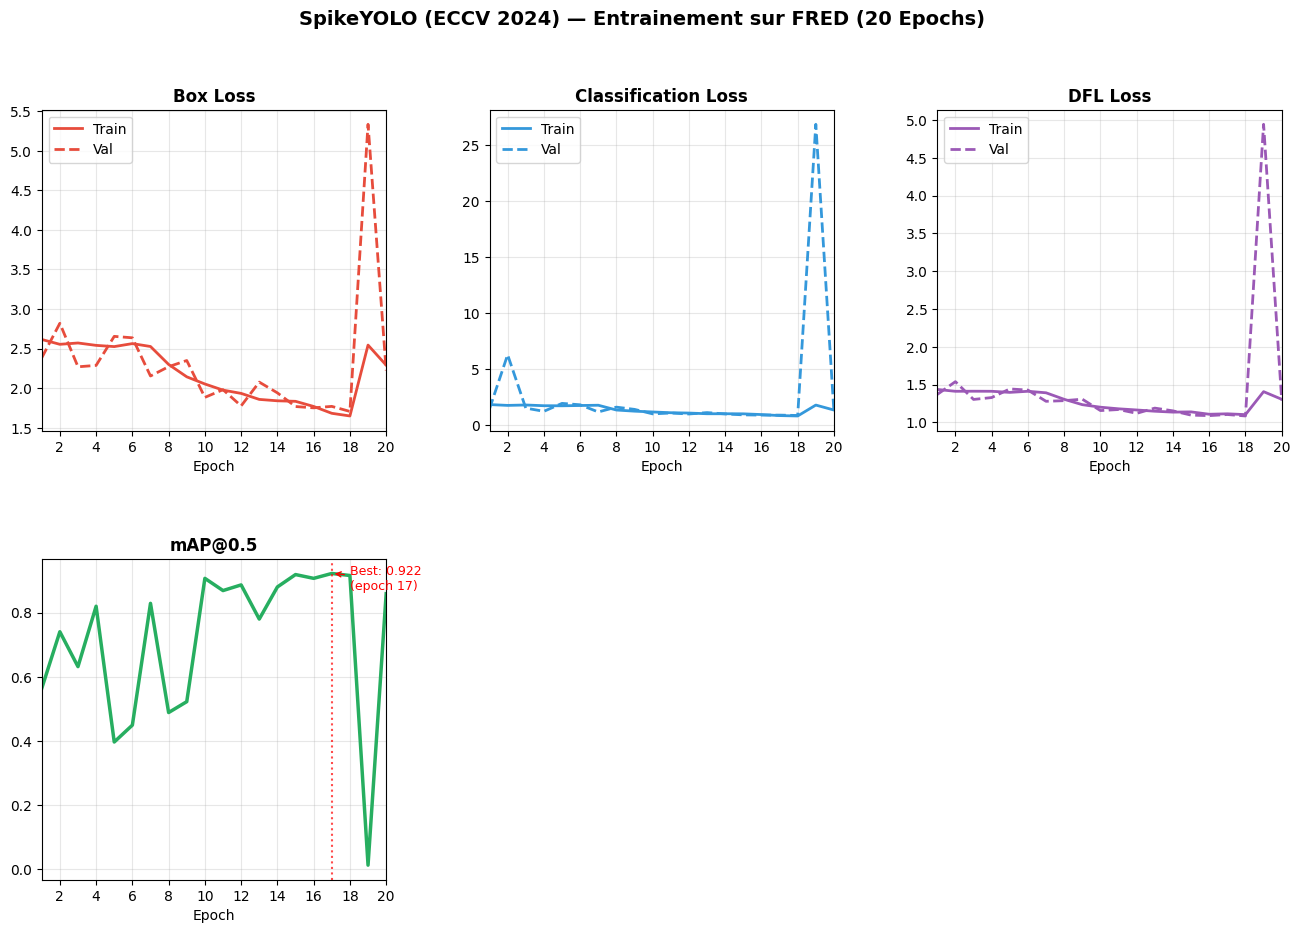

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob

# Cherche le fichier results.csv dans les runs
csv_files = glob.glob('/kaggle/working/runs_spikeyolo/**/results.csv', recursive=True)

if not csv_files:
    print('Pas encore de resultats. Lance d\'abord la cellule 6.')
else:
    csv_path = csv_files[0]
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    # MODIFICATION : On limite strictement l'analyse aux 20 premiers epochs
    df = df.head(20)
    
    print(f'Resultats charges : {len(df)} epochs')
    print(f'Colonnes : {list(df.columns)}')

    # Metriques cles
    map50    = df['metrics/mAP50(B)'].max()
    map5095  = df['metrics/mAP50-95(B)'].max()
    best_ep  = df['metrics/mAP50(B)'].idxmax() + 1
    print(f'\nMeilleur mAP@0.5     : {map50:.4f} (epoch {best_ep})')
    print(f'Meilleur mAP@0.5:0.95: {map5095:.4f}')

    epochs = df.index + 1

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)
    fig.suptitle('SpikeYOLO (ECCV 2024) — Entrainement sur FRED (20 Epochs)',
                 fontsize=14, fontweight='bold')

    # Configuration des ticks pour l'axe X (de 1 à 20)
    x_ticks = list(range(2, 21, 2))

    # Box Loss
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(epochs, df['train/box_loss'], label='Train', color='#e74c3c', lw=2)
    ax.plot(epochs, df['val/box_loss'],   label='Val',   color='#e74c3c', lw=2, ls='--')
    ax.set_title('Box Loss', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('Epoch'); ax.set_xlim(1, 20); ax.set_xticks(x_ticks)

    # Cls Loss
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(epochs, df['train/cls_loss'], label='Train', color='#3498db', lw=2)
    ax.plot(epochs, df['val/cls_loss'],   label='Val',   color='#3498db', lw=2, ls='--')
    ax.set_title('Classification Loss', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('Epoch'); ax.set_xlim(1, 20); ax.set_xticks(x_ticks)

    # DFL Loss
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(epochs, df['train/dfl_loss'], label='Train', color='#9b59b6', lw=2)
    ax.plot(epochs, df['val/dfl_loss'],   label='Val',   color='#9b59b6', lw=2, ls='--')
    ax.set_title('DFL Loss', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('Epoch'); ax.set_xlim(1, 20); ax.set_xticks(x_ticks)

    # mAP50
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, df['metrics/mAP50(B)'], color='#27ae60', lw=2.5)
    ax.axvline(best_ep, color='red', ls=':', alpha=0.7)
    
    # MODIFICATION : Rapprochement du texte de la flèche (best_ep+1 au lieu de +3)
    ax.annotate(f'Best: {map50:.3f}\n(epoch {best_ep})',
                xy=(best_ep, map50), xytext=(best_ep+1, map50-0.05),
                fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title('mAP@0.5', fontweight='bold'); ax.grid(alpha=0.3)
    ax.set_xlabel('Epoch'); ax.set_xlim(1, 20); ax.set_xticks(x_ticks)

    # mAP50-95

---
## Cellule 8 — Evaluation sur le set de validation

In [16]:
import glob
from ultralytics import YOLO

# Chargement du meilleur modele
best_models = glob.glob('/kaggle/working/runs_spikeyolo/**/best.pt', recursive=True)

if not best_models:
    print('Pas de modele sauvegarde. Lance d\'abord la cellule 6.')
else:
    BEST_MODEL = best_models[0]
    print(f'Modele charge : {BEST_MODEL}')

    model_eval = YOLO(BEST_MODEL)

    metrics = model_eval.val(
        data='/kaggle/working/fred_drone.yaml',
        imgsz=640,
        batch=16,
        device=0,
        verbose=True,
        plots=True,
        project='/kaggle/working/eval_spikeyolo',
        name='fred_eval',
        exist_ok=True,
    )

    print('\n' + '='*50)
    print('RESULTATS FINAUX SpikeYOLO sur FRED')
    print('='*50)
    print(f'  mAP@0.5       : {metrics.box.map50:.4f}')
    print(f'  mAP@0.5:0.95  : {metrics.box.map:.4f}')
    print(f'  Precision     : {metrics.box.mp:.4f}')
    print(f'  Recall        : {metrics.box.mr:.4f}')
    f1 = 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-9)
    print(f'  F1-Score      : {f1:.4f}')
    print('='*50)

Modele charge : /kaggle/working/runs_spikeyolo/fred_drone/weights/best.pt


Ultralytics YOLOv8.0.197 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
snn_YOLOv8l summary: 771 layers, 65472019 parameters, 0 gradients, 404.0 GFLOPs
val: Scanning /kaggle/working/FRED_YOLO/labels/val.cache... 3032 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3032/3032 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [03:32<00:00,  1.12s/it]
                   all       3032       3032      0.916      0.895      0.908      0.364
Speed: 0.2ms preprocess, 65.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/eval_spikeyolo/fred_eval



RESULTATS FINAUX SpikeYOLO sur FRED
  mAP@0.5       : 0.9078
  mAP@0.5:0.95  : 0.3638
  Precision     : 0.9160
  Recall        : 0.8951
  F1-Score      : 0.9054


---
## Cellule 9 — Visualisation des predictions

Affichage cote a cote : boites predites (rouge) vs ground truth (vert).

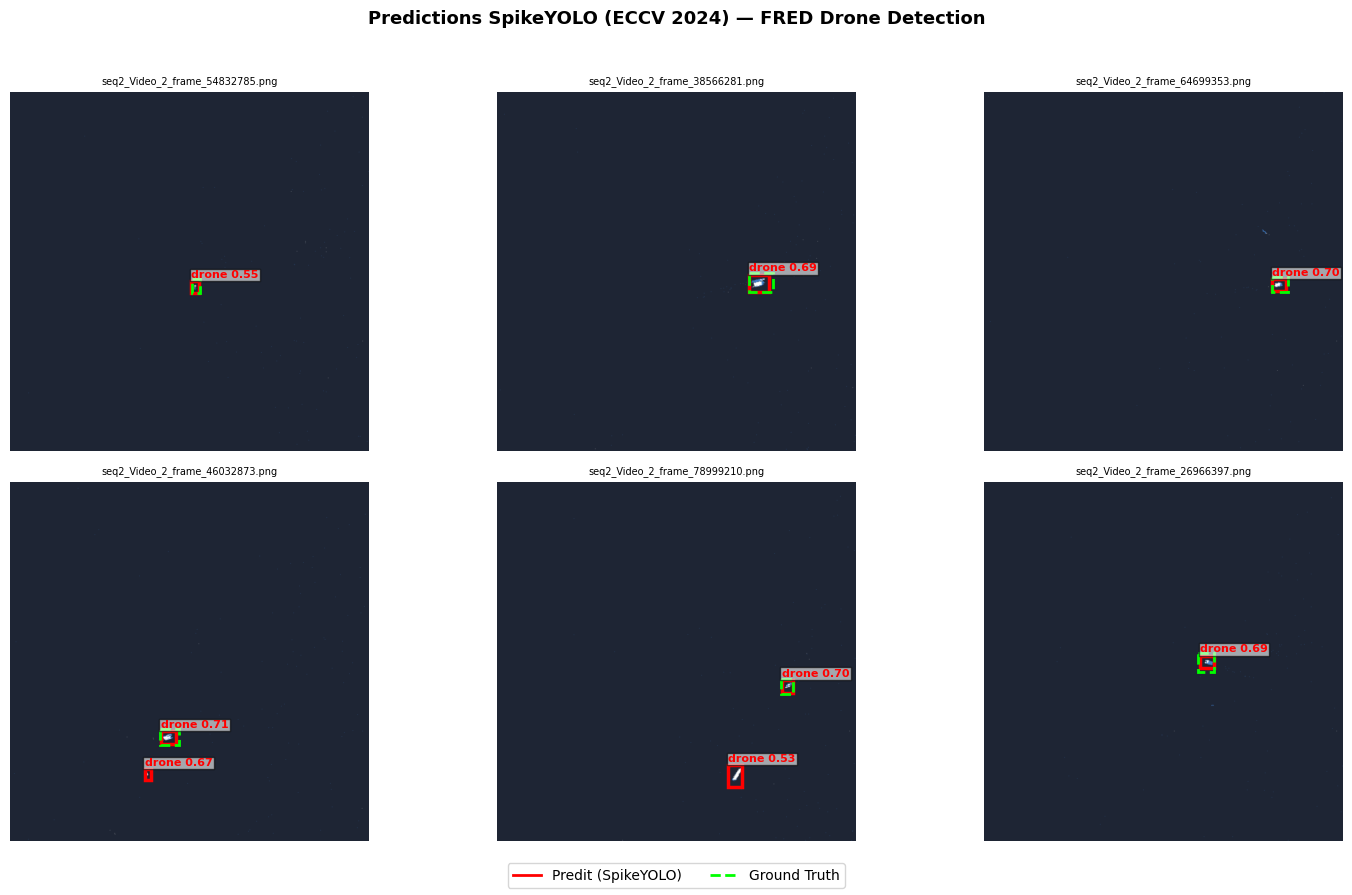

Visualisation terminee !
  Rouge = Predictions SpikeYOLO | Vert pointille = Ground Truth


In [19]:
#### import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import os

YOLO_ROOT = '/kaggle/working/FRED_YOLO'
val_imgs  = sorted(os.listdir(f'{YOLO_ROOT}/images/val'))
samples   = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Predictions SpikeYOLO (ECCV 2024) — FRED Drone Detection',
             fontsize=13, fontweight='bold')

for i, fname in enumerate(samples):
    ax       = axes[i//3][i%3]
    img_path = f'{YOLO_ROOT}/images/val/{fname}'

    # Inference SpikeYOLO
    results_inf = model_eval.predict(
        source=img_path, imgsz=640, conf=0.25, iou=0.45, verbose=False
    )

    img = Image.open(img_path).convert('RGB')
    ax.imshow(img); ax.axis('off')
    ax.set_title(fname[:35], fontsize=7)

    # Predictions (rouge)
    for r in results_inf:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0].cpu())
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                      linewidth=2.5, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-6, f'drone {conf:.2f}', color='red', fontsize=8,
                    fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, pad=1))

    # Ground truth (vert pointille)
    label_path = f'{YOLO_ROOT}/labels/val/{os.path.splitext(fname)[0]}.txt'
    if os.path.exists(label_path):
        w_img, h_img = img.size
        with open(label_path) as lf:
            for line in lf:
                cls, xc, yc, bw, bh = map(float, line.strip().split())
                x1 = (xc - bw/2) * w_img; y1 = (yc - bh/2) * h_img
                rect = patches.Rectangle((x1,y1), bw*w_img, bh*h_img,
                                          linewidth=2, edgecolor='lime',
                                          facecolor='none', linestyle='--')
                ax.add_patch(rect)

from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0],[0], color='red',  lw=2,           label='Predit (SpikeYOLO)'),
    Line2D([0],[0], color='lime', lw=2, ls='--',   label='Ground Truth'),
], loc='lower center', ncol=2, fontsize=10)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('/kaggle/working/spikeyolo_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisation terminee !')
print('  Rouge = Predictions SpikeYOLO | Vert pointille = Ground Truth')